 # Statement

 The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labeling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

 # Init

In [ ]:
import math

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm


In [ ]:
# %config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
# %config InlineBackend.figure_format = 'retina'
# plt.style.available

plt.style.use('ggplot')


In [ ]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()


 # Load Data

In [ ]:
df_reviews = pd.read_csv('https://code.s3.yandex.net/datasets/imdb_reviews.tsv', 
                         sep='\t', dtype={'votes': 'Int64'})
df_reviews.sample(5)


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
15638,tt0077651,movie,Halloween,Halloween,1978,\N,91,0,"Horror,Thriller",7.8,220534,With a simplistic story and an engaging heroin...,8,pos,1,train,7308
46236,tt0381707,movie,White Chicks,White Chicks,2004,\N,109,0,"Comedy,Crime",5.6,126766,"Basically this is an overlong, unfunny, action...",1,neg,0,train,11661
4930,tt0120611,movie,Blade,Blade,1998,\N,120,0,"Action,Horror,Sci-Fi",7.1,238274,"Interesting twist on the Vampire yarn - fast, ...",7,pos,1,test,502
34945,tt0094783,movie,The Boost,The Boost,1988,\N,95,0,"Drama,Romance",6.1,1902,This film is right up there with The Oscar and...,1,neg,0,test,7730
36008,tt0104040,movie,The Cutting Edge,The Cutting Edge,1992,\N,101,0,"Comedy,Drama,Romance",6.9,18340,Nothing about this movie is any good. It's a f...,1,neg,0,test,10907


In [ ]:
df_reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

 # EDA

 Let's check number of movies and reviews over years.

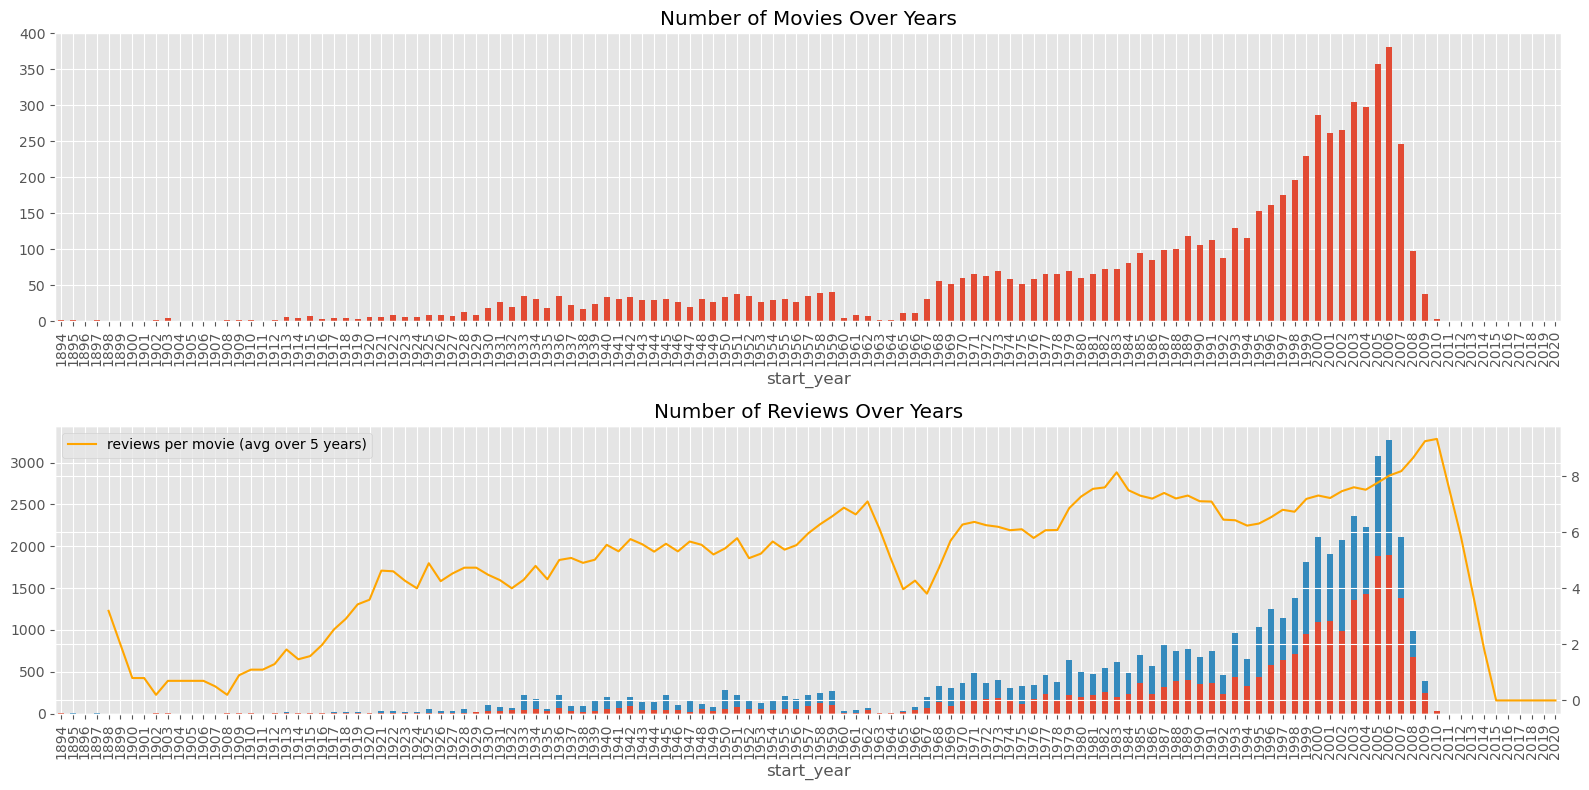

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()


 Let's check distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

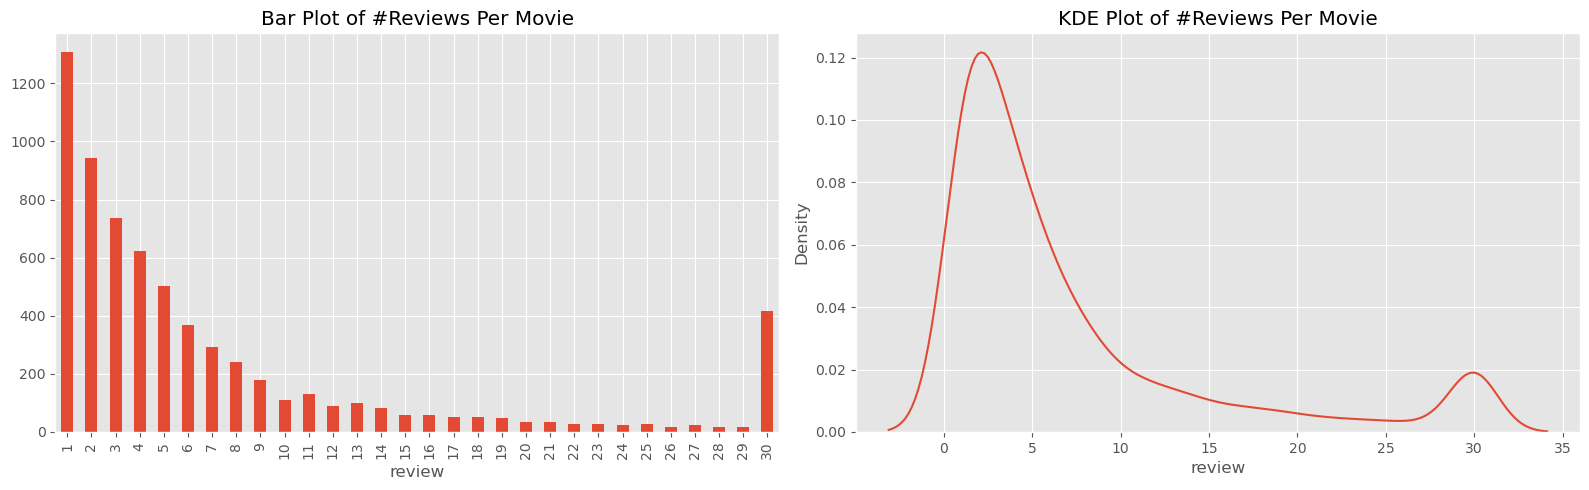

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()


In [ ]:
df_reviews['pos'].value_counts()


pos
0    23715
1    23616
Name: count, dtype: int64

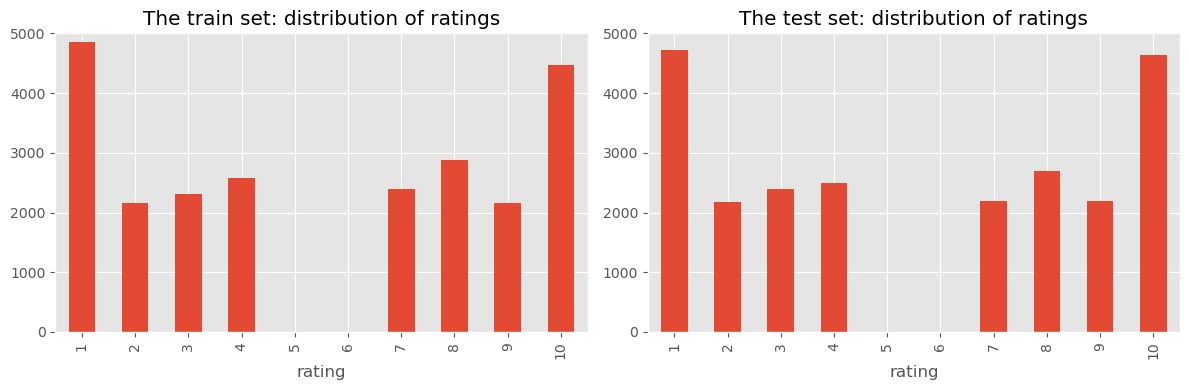

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()


 Distribution of negative and positive reviews over years for two parts of the dataset

/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_23469/474925111.py:22: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_23469/474925111.py:23: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipykernel_23469/474925111.py:38: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
/var/folders/fm/f0cwhq8j4kq9xqtssrxv062m0000gn/T/ipyke

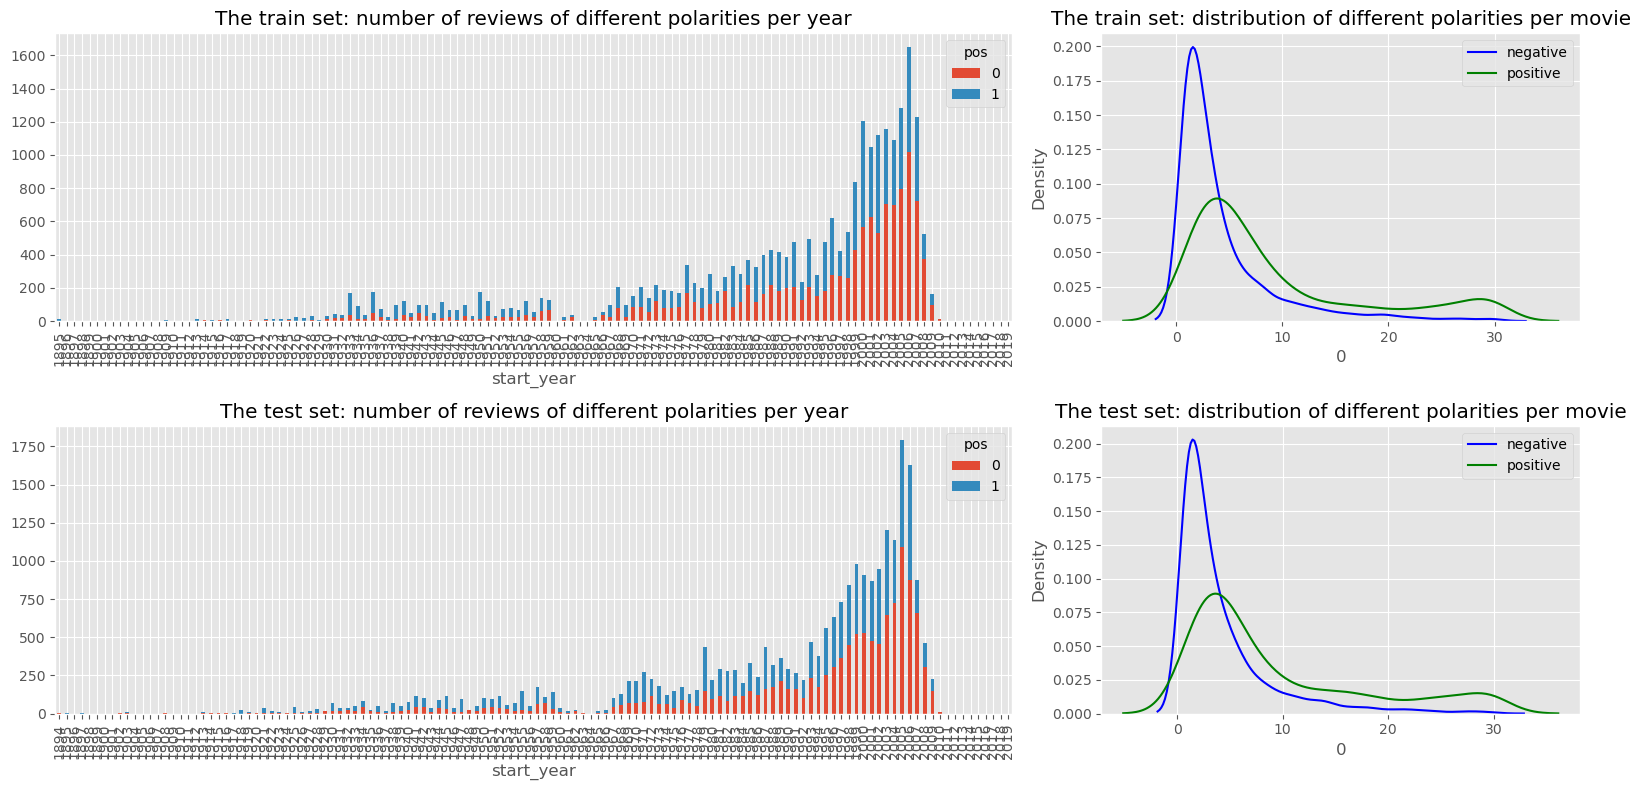

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))
# fig = plt.figure(figsize=(16, 8), constrained_layout=True)

# gs = fig.add_gridspec(3, 2)
# ax1 = fig.add_subplot(gs[0, :-1])
# ax2 = fig.add_subplot(gs[0, -1])
# ax3 = fig.add_subplot(gs[1, :-1])
# ax4 = fig.add_subplot(gs[1, -1])

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()


 # Evaluation Procedure

 Composing an evaluation routine which can be used for all models in this project

In [ ]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return


 # Normalization

 We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [ ]:
df_reviews['review_norm'] = df_reviews['review'].str.lower().str.replace('[^a-zA-Z]', ' ')


 # Train / Test Split

 Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [ ]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)


(23796, 18)
(23535, 18)


 # Model 0 - Constant

          train  test
Accuracy   0.50  0.50
F1         0.67  0.67
APS        0.50  0.50
ROC AUC    0.50  0.50


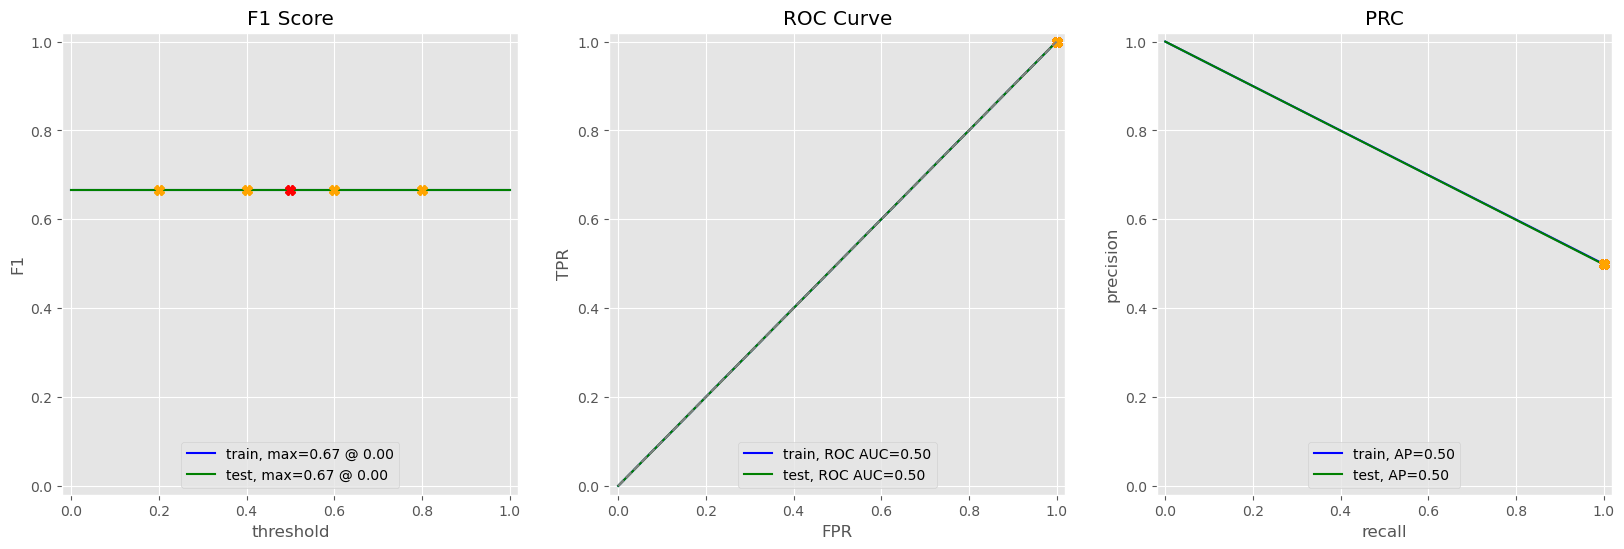

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='constant', constant=1)
#dummy_clf = DummyClassifier(strategy='most_frequent')

model_0 = dummy_clf.fit(X=df_reviews_train, y=train_target)

evaluate_model(model_0, np.empty(len(train_target)), train_target, np.empty(len(test_target)), test_target)


 # Model 1 - NLTK, TF-IDF and LR

 ### TF-IDF

In [ ]:
import nltk

nltk.download('wordnet')
nltk.download('stopwords')

from nltk.corpus import stopwords


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/juliokorleone/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/juliokorleone/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer_1 = TfidfVectorizer(stop_words=stopwords.words('english'), lowercase=True)


In [ ]:
train_features = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
print(train_features.shape)


(23796, 73081)


In [ ]:
test_features = tfidf_vectorizer_1.transform(df_reviews_test['review_norm'])
print(train_features.shape)


(23796, 73081)


In [ ]:
from sklearn.linear_model import LogisticRegression

model_1 = LogisticRegression()

model_1.fit(train_features, train_target)


LogisticRegression()

          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


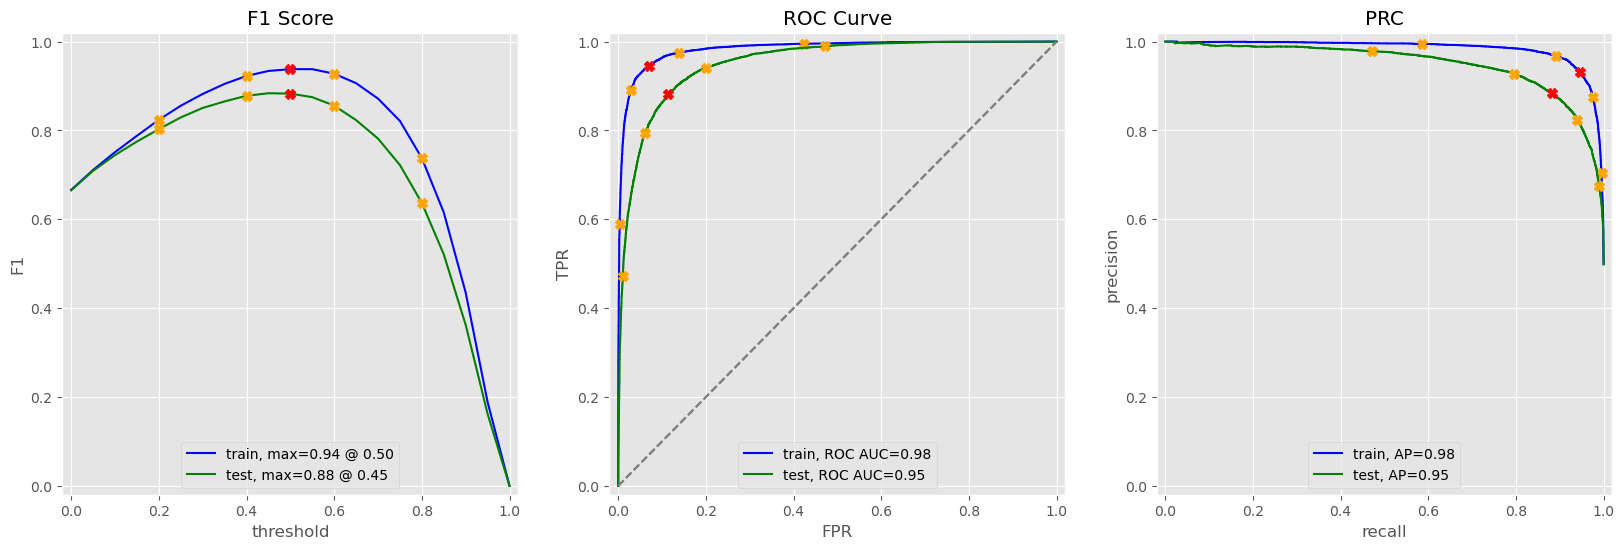

In [ ]:
evaluate_model(model_1, train_features, train_target, test_features, test_target)


 # Model 3 - spaCy, TF-IDF and LR

In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


In [ ]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)


In [ ]:
df_reviews_train['review_tokenized_3'] = df_reviews_train['review_norm'].progress_apply(lambda x: text_preprocessing_3(x))


  0%|          | 0/23796 [00:00<?, ?it/s]

In [ ]:
df_reviews_test['review_tokenized_3'] = df_reviews_test['review_norm'].progress_apply(lambda x: text_preprocessing_3(x))


  0%|          | 0/23535 [00:00<?, ?it/s]

In [ ]:
df_reviews_train['review_tokenized_3'].sample(5)


43815    back in 1997 , do I remember that year : clint...
33323    melissa 's sixteenth birthday be right around ...
40816    I go to school with jeremy earl , that be how ...
8239     all logic go straight out of the train window ...
39469    speak solely as a movie , I do not really like...
Name: review_tokenized_3, dtype: object

In [ ]:
df_reviews_test['review_tokenized_3'].sample(5)


25474    with two old friend . I have always enjoy both...
42911    the beginning voice over sound like ' the wind...
6113     I have be play this movie incessantly this mon...
20269    the first time I have see this dvd , I be not ...
14210    this movie be like porn with all of the good p...
Name: review_tokenized_3, dtype: object

In [ ]:
tfidf_vectorizer_3 = TfidfVectorizer()

train_features_3 = tfidf_vectorizer_3.fit_transform(df_reviews_train['review_tokenized_3'])
print(train_features_3.shape)


(23796, 61294)


In [ ]:
test_features_3 = tfidf_vectorizer_3.transform(df_reviews_test['review_tokenized_3'])
print(train_features_3.shape)


(23796, 61294)


In [ ]:
from sklearn.linear_model import LogisticRegression
model_3 = LogisticRegression()
model_3.fit(train_features_3, train_target)


LogisticRegression()

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


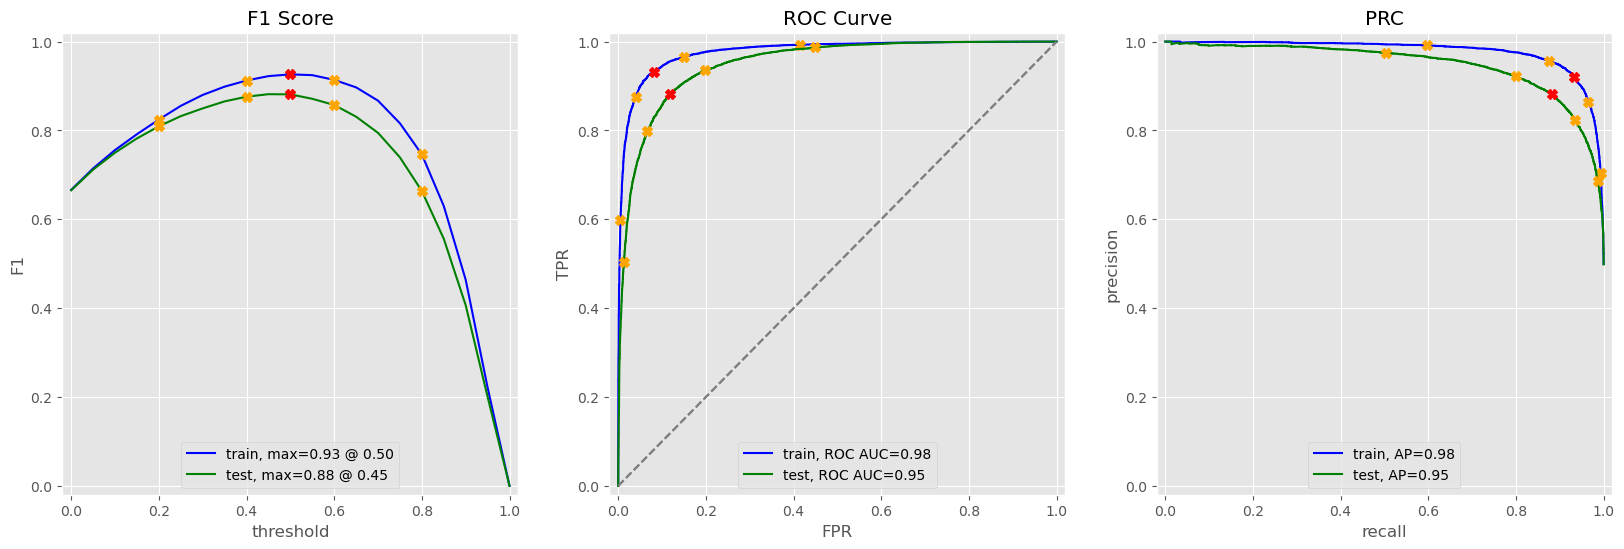

In [ ]:
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)

 # Model 4 - spaCy, TF-IDF and LGBMClassifier

In [ ]:
from lightgbm import LGBMClassifier
model_4 = LGBMClassifier(learning_rate=.1)
model_4.fit(train_features_3, train_target)

[LightGBM] [Info] Number of positive: 11884, number of negative: 11912
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.230233 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 486838
[LightGBM] [Info] Number of data points in the train set: 23796, number of used features: 9664
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499412 -> initscore=-0.002353
[LightGBM] [Info] Start training from score -0.002353


LGBMClassifier()

          train  test
Accuracy   0.92  0.86
F1         0.92  0.86
APS        0.98  0.94
ROC AUC    0.98  0.94


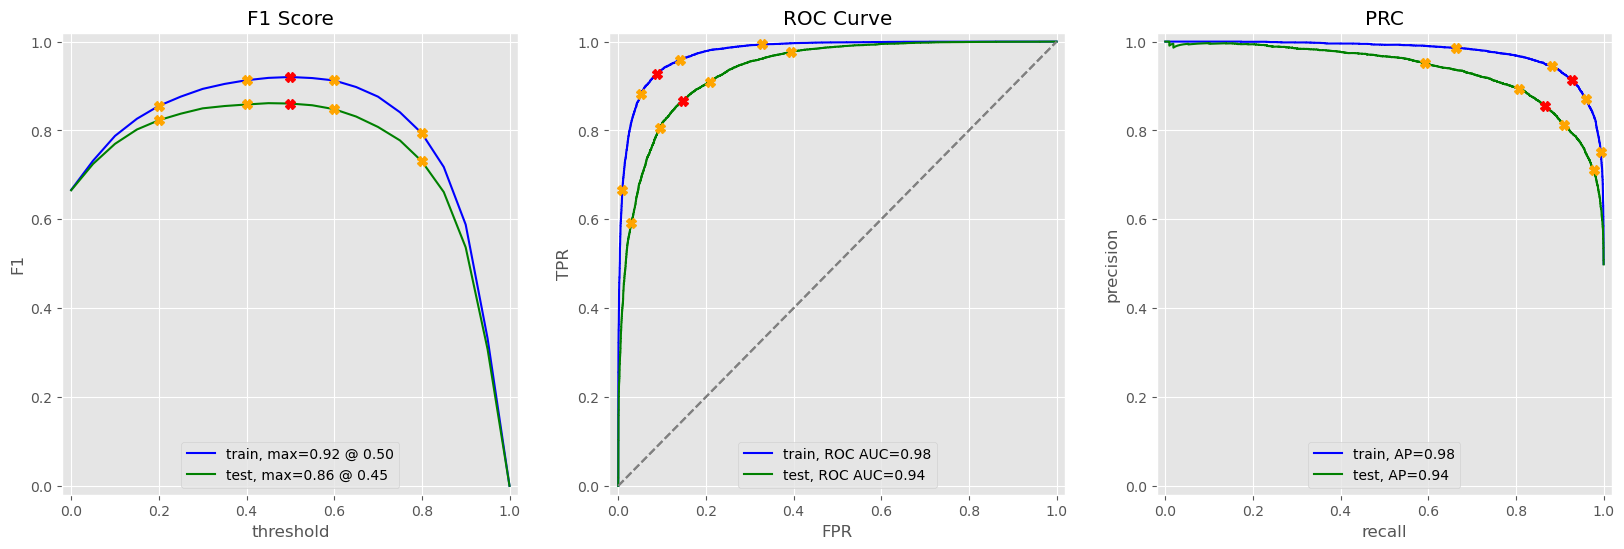

In [ ]:
evaluate_model(model_4, train_features_3, train_target, test_features_3, test_target)

 #  Model 9 - BERT

In [ ]:
# SE DEBE USAR TARJETA NVIDIA PARA SOPORTE CUDA
# import torch
# import transformers


In [ ]:
# tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
# config = transformers.BertConfig.from_pretrained('bert-base-uncased')
# model = transformers.BertModel.from_pretrained('bert-base-uncased')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/opt/anaconda3/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # text to padded ids of tokens along with their attention masks
    
    #for input_text in tqdm(texts, disable=disable_progress_bar):
    for input_text in texts:
        ids = tokenizer.encode(input_text.lower(), add_special_tokens=True, truncation=True, max_length=max_length)
        padded = np.array(ids + [0]*(max_length - len(ids)))  # add zeros --> list = list +[0]*2
        attention_mask = np.where(padded != 0, 1, 0)
        ids_list.append(padded)
        attention_mask_list.append(attention_mask)
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Using the {device} device.')
    
    # gettings embeddings in batches

    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_list[batch_size*i:batch_size*(i+1)]).to(device)
            
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
    return np.concatenate(embeddings)


In [ ]:
#    for txt in texts:
#        ids = tokenizer.encode(txt.lower(), add_special_tokens=True, max_length=max_length, truncation=True)
#         longintud = ids
#         diferencia = max_length - len(ids)
#         lista = ids + [0] * diferencia
#         ids_list.append(lista)

#         mask_list = [] 
#         mask_list = mask_list + [1] * len(lista) + [0] * diferencia
#         attention_mask_list.append(mask_list)

In [ ]:
# Attention! Running BERT for thousands of texts may take long run on CPU, several hours
# train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cpu')


In [ ]:
# print(df_reviews_train['review_norm'].shape)
# print(train_features_9.shape)
# print(train_target.shape)


(23796,)


NameError: name 'train_features_9' is not defined

In [ ]:
# Attention! Running BERT for thousands of texts may take long run on CPU, several hours
#test_features_9 = BERT_text_to_embeddings(df_reviews_test['review_norm'], force_device='cuda')


In [ ]:
# print(df_reviews_test['review_norm'].shape)
# print(test_features_9.shape)
# print(test_target.shape)


In [ ]:
# if you have got the embeddings, it's advisable to save them to have them ready if 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# and load...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']


In [ ]:
from sklearn.linear_model import LogisticRegression

model_9 = LogisticRegression(max_iter=1000)

# solo para BERT
# model_9.fit(train_features_9, train_target)
model_9.fit(train_features_3, train_target)


LogisticRegression(max_iter=1000)

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


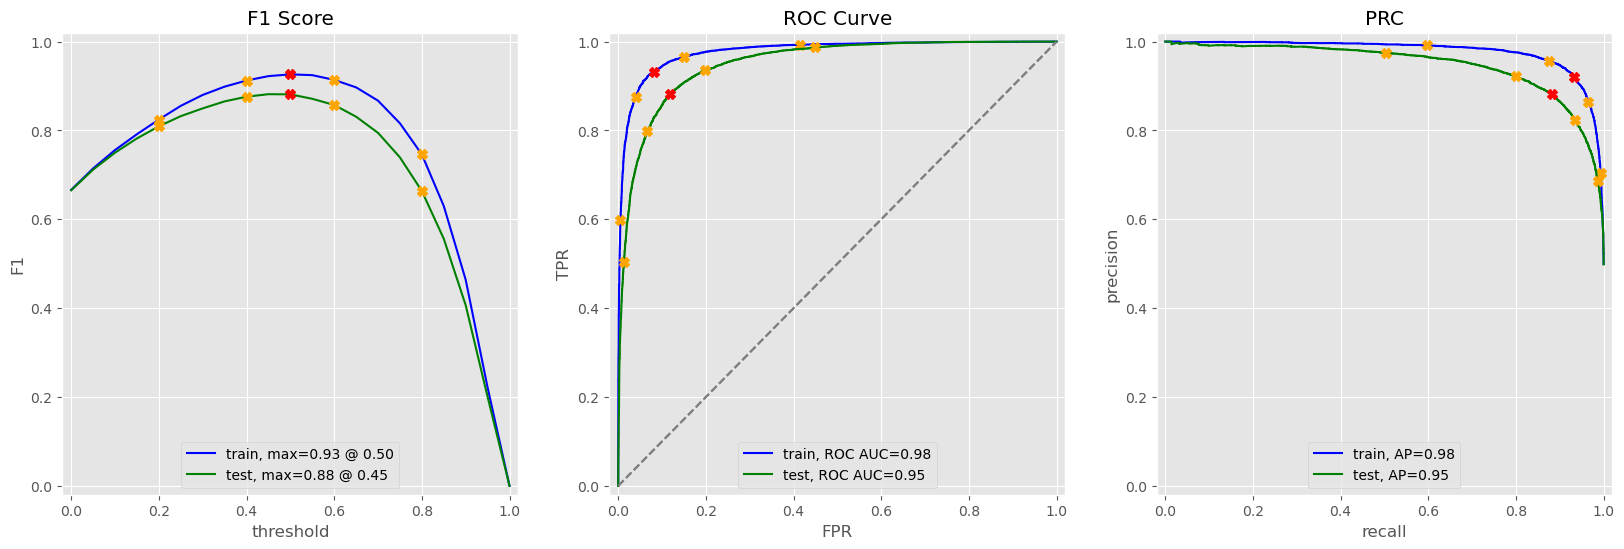

In [ ]:
# SOLO BERT
#evaluate_model(model_9, train_features_9, train_target, test_features_9, test_target)
evaluate_model(model_9, train_features_3, train_target, test_features_3, test_target)


 # My Reviews

In [52]:
# %%
# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].str.lower().str.replace('[^a-zA-Z]', ' ')

my_reviews


,review,review_norm
0,"I did not simply like it, not my kind of movie.","i did not simply like it, not my kind of movie."
1,"Well, I was bored and felt asleep in the middl...","well, i was bored and felt asleep in the middl..."
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn't expect the reboot to be so good! writ...
5,"The movie had its upsides and downsides, but I...","the movie had its upsides and downsides, but i..."
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy. not a singl...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move & i real...


 ## Model 1

In [ ]:
texts = my_reviews['review_norm']

my_reviews_features_1 = tfidf_vectorizer_1.transform(texts)
my_reviews_pred_prob = model_1.predict_proba(my_reviews_features_1)[:, 1]
my_reviews_pred = model_1.predict(my_reviews_features_1)

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}  {my_reviews_pred[i]}:  {review}')


0.14  0:  i did not simply like it, not my kind of movie.
0.16  0:  well, i was bored and felt asleep in the middle of the movie.
0.53  1:  i was really fascinated with the movie
0.11  0:  even the actors looked really old and disinterested, and they got paid to be in the movie. what a so
0.30  0:  i didn't expect the reboot to be so good! writers really cared about the source material
0.47  0:  the movie had its upsides and downsides, but i feel like overall it's a decent flick. i could see my
0.04  0:  what a rotten attempt at a comedy. not a single joke lands, everyone acts annoying and loud, even ki
0.82  1:  launching on netflix was a brave move & i really appreciate being able to binge on episode after epi


 ## Model 3

In [ ]:
texts = my_reviews['review_norm']

my_reviews_features_3 = tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x)))
my_reviews_pred_prob = model_3.predict_proba(my_reviews_features_3)[:, 1]
my_reviews_pred = model_3.predict(my_reviews_features_3)

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}  {my_reviews_pred[i]}:  {review}')


0.17  0:  i did not simply like it, not my kind of movie.
0.24  0:  well, i was bored and felt asleep in the middle of the movie.
0.48  0:  i was really fascinated with the movie
0.15  0:  even the actors looked really old and disinterested, and they got paid to be in the movie. what a so
0.19  0:  i didn't expect the reboot to be so good! writers really cared about the source material
0.68  1:  the movie had its upsides and downsides, but i feel like overall it's a decent flick. i could see my
0.03  0:  what a rotten attempt at a comedy. not a single joke lands, everyone acts annoying and loud, even ki
0.87  1:  launching on netflix was a brave move & i really appreciate being able to binge on episode after epi


 ## Model 4

In [ ]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_features_4 = tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x)))
my_reviews_pred_prob = model_4.predict_proba(my_reviews_features_4)[:, 1]
my_reviews_pred = model_4.predict(my_reviews_features_4)

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}  {my_reviews_pred[i]}:  {review}')


0.53  1:  i did not simply like it, not my kind of movie.
0.53  1:  well, i was bored and felt asleep in the middle of the movie.
0.63  1:  i was really fascinated with the movie
0.63  1:  even the actors looked really old and disinterested, and they got paid to be in the movie. what a so
0.54  1:  i didn't expect the reboot to be so good! writers really cared about the source material
0.76  1:  the movie had its upsides and downsides, but i feel like overall it's a decent flick. i could see my
0.21  0:  what a rotten attempt at a comedy. not a single joke lands, everyone acts annoying and loud, even ki
0.79  1:  launching on netflix was a brave move & i really appreciate being able to binge on episode after epi


 ## Model 9

In [ ]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]
my_reviews_pred = model_9.predict(my_reviews_features_9)

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}  {my_reviews_pred[i]}:  {review}')


 # Conclusions

 - There are slightly different way to turn text into tokens and lemmas.

 - There are different way to turn texts into vectors.

 - The simple model TF-IDF + LogisticRegression provides a good quality given the target metrics.

 - Lemmatization with spaCy does not seem to help much.

 - BERT takes a lot of time on CPU but much less on GPU.

 - Classification model based on language model (BERT) shows metrics (accuracy, F1 etc) is of similar values to less complex models but seems to be more dividing (the probabilities are more 'polarized') and less prone to overfitting.

 # Check List

 - [x]  Notebook was opened

 - [ ]  The text data is loaded and pre-processed for vectorization

 - [ ]  The text data is transformed to vectors

 - [ ]  Models are trained and tested

 - [ ]  The metric's threshold is reached

 - [ ]  All the code cells are arranged in the order of their execution

 - [ ]  All the code cells can be executed without errors

 - [ ]  There are conclusions